# 🚗 Preditor de Preço Justo — Toyota Corolla Sedã (SP)
Disciplina: Inteligência Artificial
Integrantes:
 - Gabriel Neman Silva    - 10403348 (Turma 7K)
 - Nicolas Gonçalves      - 10418047 (Turma 7K)
 - Gabriel Pastorelli     - 10419046 (Turma 7K)
 - Nicolai Zeroshenko     - 10417221 (Turma 7J)

 Síntese: Notebook unificado do projeto N2 — pipeline completo de Machine
 Learning para precificação do Toyota Corolla Sedã em SP. Realiza upload do
 dataset bruto, processamento ETL (limpeza, outliers via IQR e filtro FIPE),
 análise exploratória de dados (estatísticas, correlações e gráficos),
 treinamento de RandomForestRegressor com proteção contra overfitting/data
 leakage, e interface interativa de previsão via ipywidgets.

 Histórico de Alterações:
 - 18/03/2026 | Gabriel Neman Silva  | N1: Coleta inicial dos dados via Selenium e BeautifulSoup (991 anúncios).
 - 22/03/2026 | Gabriel Pastorelli   | N1: Implementação do pipeline ETL com limpeza e tratamento de outliers.
 - 22/03/2026 | Nicolai Zeroshenko   | N1: Análise Exploratória de Dados e visualizações com Seaborn.
 - 24/03/2026 | Grupo                | N1: Revisão final e entrega do Relatório.
 - 14/05/2026 | Nicolas Gonçalves    | N2: Criação do notebook unificado integrando o pipeline local ao Colab.
 - 22/05/2026 | Nicolai Zeroshenko   | N2: Adição da seção 3.5 de EDA com gráficos e correlações de Pearson.
 - 24/05/2026 | Grupo                | N2: Validação final dos resultados (R² 93,96% / MAE R$ 5.619,09).

**Fluxo do notebook:**

- Upload do dataset bruto
- Processamento (ETL)
- Análise Exploratória (EDA) ← nova etapa
- Treinamento
- Previsão Interativa


## 1. Setup

Imports e instalação.

In [2]:
!pip install -q pandas scikit-learn joblib ipywidgets matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 89.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import ipywidgets as widgets
from IPython.display import display, clear_output

## 2. Upload do dataset bruto

Upload do `COROLLA_SP_BRUTO.csv` (gerado pelo `main.py` rodando localmente).

In [4]:
from google.colab import files
uploaded = files.upload()  # selecione o COROLLA_SP_BRUTO.csv

Saving COROLLA_SP_BRUTO.csv to COROLLA_SP_BRUTO.csv


## 3. Processamento (ETL)

Pipeline de limpeza do dataset bruto:

- Remove cabeçalhos perdidos no meio das linhas (efeito colateral do `mode='a'` da coleta)
- Trata espaços vazios como `NaN` e dropa qualquer linha com nulo
- Tipagem rigorosa das colunas numéricas
- **Outliers por IQR** em `Preco_Real` e `Quilometragem` — qualquer valor além de Q1−1.5·IQR ou Q3+1.5·IQR vai fora
- **Limite de sanidade no FIPE**: aceita só anúncios entre 50% e 150% da tabela (muito baixo costuma esconder problema mecânico; muito alto é blindado ou anúncio errado)
- Dropa colunas constantes (Marca, Modelo, Estado, Carroceria — todas iguais no dataset filtrado, não servem pra IA)

In [5]:
nome_arquivo_entrada = 'COROLLA_SP_BRUTO.csv'
nome_arquivo_saida   = 'COROLLA_SP_ML_FINAL.csv'

print("🚀 Iniciando ETL...")
df = pd.read_csv(nome_arquivo_entrada, dtype=str)

linhas_originais = len(df)
print(f"📊 Linhas originais: {linhas_originais}")

# === Etapa 1: limpeza básica ===
print("\n🧹 [Etapa 1] Limpeza e tipagem...")

df = df[df['Marca'] != 'Marca']  # remove cabeçalhos perdidos

df = df.apply(lambda col: col.str.strip())
df = df.replace('', pd.NA)
df = df.replace(r'^\s*$', pd.NA, regex=True)

df.dropna(how='any', inplace=True)
df.drop_duplicates(subset=['ID_Anuncio'], inplace=True)

colunas_numericas = ['Preco_Real', 'Quilometragem', 'Percentual_FIPE',
                     'Ano_Fabricacao', 'Ano_Modelo']
for col in colunas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=colunas_numericas, inplace=True)
df['Ano_Fabricacao'] = df['Ano_Fabricacao'].astype(int)
df['Ano_Modelo']     = df['Ano_Modelo'].astype(int)
df['Quilometragem']  = df['Quilometragem'].astype(int)

linhas_pos_limpeza = len(df)
print(f" ✔ Linhas após limpeza: {linhas_pos_limpeza}")

# === Etapa 2: outliers ===
print("\n🔍 [Etapa 2] Outliers (IQR + FIPE)...")

def remover_outliers_iqr(dataframe, coluna):
    Q1 = dataframe[coluna].quantile(0.25)
    Q3 = dataframe[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    filtro = (dataframe[coluna] >= limite_inf) & (dataframe[coluna] <= limite_sup)
    return dataframe[filtro], len(dataframe) - filtro.sum()

df, rem_preco = remover_outliers_iqr(df, 'Preco_Real')
print(f" ✔ Preço_Real    — removidos: {rem_preco}")

df, rem_km = remover_outliers_iqr(df, 'Quilometragem')
print(f" ✔ Quilometragem — removidos: {rem_km}")

antes = len(df)
df = df[(df['Percentual_FIPE'] >= 50) & (df['Percentual_FIPE'] <= 150)]
rem_fipe = antes - len(df)
print(f" ✔ Percentual_FIPE — removidos: {rem_fipe}")

# === Etapa 3: drop de colunas constantes ===
print("\n✂️ [Etapa 3] Dropando colunas que não servem pra IA...")
df.drop(columns=['ID_Anuncio', 'Marca', 'Modelo', 'Carroceria', 'Estado'],
        inplace=True, errors='ignore')

# === Etapa 4: salvamento ===
df.to_csv(nome_arquivo_saida, index=False, encoding='utf-8-sig')

print("\n" + "="*50)
print("✅ ETL CONCLUÍDO")
print(f"📊 Originais: {linhas_originais}")
print(f"🗑️ Lixo/NaN:  {linhas_originais - linhas_pos_limpeza}")
print(f"🗑️ Outliers:  {rem_preco + rem_km + rem_fipe}")
print(f"🎯 Finais:    {len(df)}")
print(f"📁 Salvo em:  {nome_arquivo_saida}")
print("="*50)

🚀 Iniciando ETL...
📊 Linhas originais: 3470

🧹 [Etapa 1] Limpeza e tipagem...
 ✔ Linhas após limpeza: 3463

🔍 [Etapa 2] Outliers (IQR + FIPE)...
 ✔ Preço_Real    — removidos: 58
 ✔ Quilometragem — removidos: 87
 ✔ Percentual_FIPE — removidos: 7

✂️ [Etapa 3] Dropando colunas que não servem pra IA...

✅ ETL CONCLUÍDO
📊 Originais: 3470
🗑️ Lixo/NaN:  7
🗑️ Outliers:  152
🎯 Finais:    3311
📁 Salvo em:  COROLLA_SP_ML_FINAL.csv


## 3.5 Análise Exploratória de Dados (EDA)


In [6]:
# Carrega o dataset limpo e mostra estatísticas descritivas
df_eda = pd.read_csv('COROLLA_SP_ML_FINAL.csv')

print(f"📊 Total de anúncios: {len(df_eda)}")
print(f"📊 Versões únicas: {df_eda['Versao'].nunique()}")
print(f"📊 Câmbios: {df_eda['Cambio'].unique().tolist()}")
print(f"📊 Ano do modelo: {df_eda['Ano_Modelo'].min()} a {df_eda['Ano_Modelo'].max()}\n")

print("=== Estatísticas descritivas ===")
print(df_eda[['Preco_Real', 'Quilometragem', 'Ano_Modelo']].describe().round(2))

📊 Total de anúncios: 3311
📊 Versões únicas: 26
📊 Câmbios: ['Automática', 'CVT', 'Manual', 'Automatizada']
📊 Ano do modelo: 1998 a 2026

=== Estatísticas descritivas ===
       Preco_Real  Quilometragem  Ano_Modelo
count     3311.00        3311.00     3311.00
mean    117916.18       83076.04     2019.75
std      37655.05       51641.00        4.64
min      18900.00           0.00     1998.00
25%      86900.00       45051.00     2017.00
50%     121900.00       78658.00     2021.00
75%     142495.00      115000.00     2023.00
max     221607.00      230000.00     2026.00


### Visualizações

- **Scatter (esquerda)**: dispersão de preço por quilometragem — espera-se nuvem inclinada negativamente
- **Boxplot (direita)**: distribuição de preço por ano de modelo — espera-se progressão crescente das medianas

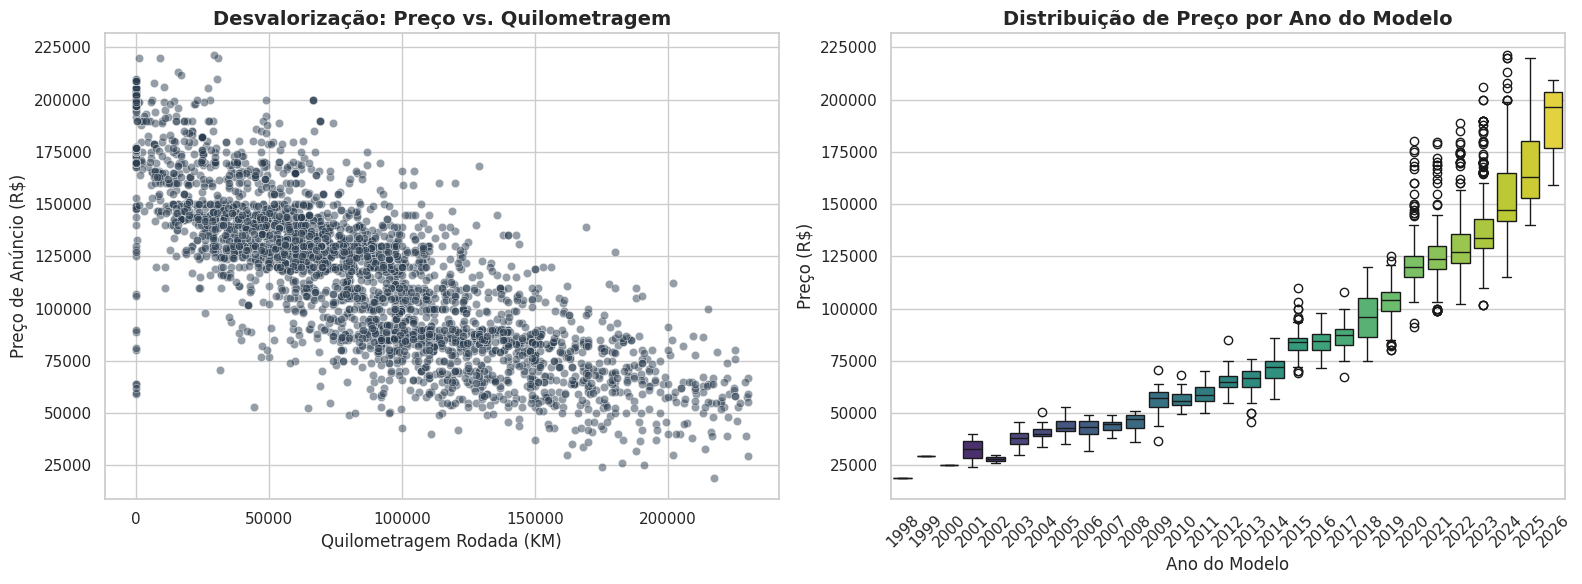


💾 Figura salva como 'eda_corolla.png' (pode anexar no artigo)


In [7]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: dispersão KM × Preço
sns.scatterplot(
    data=df_eda, x='Quilometragem', y='Preco_Real',
    alpha=0.5, color='#2c3e50', ax=axes[0]
)
axes[0].set_title('Desvalorização: Preço vs. Quilometragem', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quilometragem Rodada (KM)', fontsize=12)
axes[0].set_ylabel('Preço de Anúncio (R$)', fontsize=12)
axes[0].ticklabel_format(style='plain', axis='both')

# Gráfico 2: boxplot Ano × Preço
sns.boxplot(
    data=df_eda, x='Ano_Modelo', y='Preco_Real',
    palette='viridis', ax=axes[1], hue='Ano_Modelo', legend=False
)
axes[1].set_title('Distribuição de Preço por Ano do Modelo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ano do Modelo', fontsize=12)
axes[1].set_ylabel('Preço (R$)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_corolla.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Figura salva como 'eda_corolla.png' (pode anexar no artigo)")

### Validação numérica das hipóteses


In [8]:
corr_km  = df_eda['Preco_Real'].corr(df_eda['Quilometragem'])
corr_ano = df_eda['Preco_Real'].corr(df_eda['Ano_Modelo'])

print("📐 Correlações de Pearson com Preco_Real:")
print(f"   Quilometragem: {corr_km:+.3f}  (esperado: negativo forte)")
print(f"   Ano do Modelo: {corr_ano:+.3f}  (esperado: positivo forte)")

if corr_km < -0.5 and corr_ano > 0.5:
    print("\n✅ Hipóteses do projeto confirmadas empiricamente.")
else:
    print("\n⚠️ Correlações fora do esperado — investigar o dataset.")

📐 Correlações de Pearson com Preco_Real:
   Quilometragem: -0.808  (esperado: negativo forte)
   Ano do Modelo: +0.907  (esperado: positivo forte)

✅ Hipóteses do projeto confirmadas empiricamente.


## 4. Treinamento

`RandomForestRegressor` com 150 árvores e `min_samples_leaf=5`. Essa restrição obriga cada folha da árvore a representar pelo menos 5 carros — evita decorar casos isolados e força generalização (protege contra **overfitting**).

Removemos `Percentual_FIPE` do X porque ele é praticamente uma função do `Preco_Real` — usar isso na hora de treinar seria **data leakage** (o modelo trapaceia usando uma variável derivada do que queremos prever, dando R² artificialmente alto que não se sustenta em produção).

Salvamos dois artefatos:

- **`modelo_corolla.pkl`** — o modelo treinado em si
- **`colunas_treinamento.pkl`** — a ordem exata das colunas após o one-hot encoding. Sem isso, na hora de prever um carro novo, as colunas geradas pelo `get_dummies()` viriam fora de ordem ou faltariam algumas (versões que só apareciam no treino), e o modelo daria erro ou previsão completamente errada

In [9]:
print("🧠 Treinando o modelo...")
df = pd.read_csv('COROLLA_SP_ML_FINAL.csv')

# Separa target e features (sem o FIPE pra evitar data leakage)
y = df['Preco_Real']
X = df.drop(columns=['Preco_Real', 'Percentual_FIPE'])

print(f"📊 Total de registros: {len(df)}")

# One-hot encoding das categóricas
X = pd.get_dummies(X, columns=['Versao', 'Cambio'], drop_first=True)

# Salva a ordem das colunas (essencial pra previsão depois)
colunas_treinamento = X.columns
joblib.dump(colunas_treinamento, 'colunas_treinamento.pkl')

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"📚 Treino: {len(X_train)} | 📝 Teste: {len(X_test)}")

# Treinamento
modelo = RandomForestRegressor(
    n_estimators=150,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
modelo.fit(X_train, y_train)

# Avaliação
previsoes = modelo.predict(X_test)
mae = mean_absolute_error(y_test, previsoes)
r2 = r2_score(y_test, previsoes)

print("\n" + "="*50)
print("🏆 RESULTADOS")
print(f"🎯 R² (precisão geral): {r2*100:.2f}%")
print(f"💸 MAE (erro médio):    R$ {mae:,.2f}")
print("="*50)

# Salva o modelo
joblib.dump(modelo, 'modelo_corolla.pkl')
print("\n✅ Modelo salvo em modelo_corolla.pkl")

🧠 Treinando o modelo...
📊 Total de registros: 3311
📚 Treino: 2648 | 📝 Teste: 663

🏆 RESULTADOS
🎯 R² (precisão geral): 93.96%
💸 MAE (erro médio):    R$ 5,619.09

✅ Modelo salvo em modelo_corolla.pkl


### Baixar os artefatos (opcional)


In [ ]:
import zipfile

with zipfile.ZipFile('artefatos_corolla.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('modelo_corolla.pkl')
    zf.write('colunas_treinamento.pkl')
    zf.write('COROLLA_SP_ML_FINAL.csv')

print("✅ Zip criado: artefatos_corolla.zip")

from google.colab import files
files.download('artefatos_corolla.zip')

✅ Zip criado: artefatos_corolla.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Previsão Interativa

Interface com `ipywidgets` em vez de `input()` — nativa do notebook. Os dropdowns de **Versão** e **Câmbio** filtram dinamicamente conforme você muda o **Ano** (mesma lógica do seu `prever_interativo.py`, só que em forma de UI).

Selecione os parâmetros e clique no botão pra estimar o preço.

In [10]:
modelo = joblib.load('modelo_corolla.pkl')
colunas_treinamento = joblib.load('colunas_treinamento.pkl')
df_base = pd.read_csv(
    'COROLLA_SP_ML_FINAL.csv',
    usecols=['Ano_Fabricacao', 'Ano_Modelo', 'Versao', 'Cambio']
)

anos_fab = sorted(df_base['Ano_Fabricacao'].unique().tolist())
anos_mod = sorted(df_base['Ano_Modelo'].unique().tolist())

# Widgets
w_ano_fab = widgets.Dropdown(options=anos_fab, value=anos_fab[-1], description='Ano Fab.:')
w_ano_mod = widgets.Dropdown(options=anos_mod, value=anos_mod[-1], description='Ano Mod.:')
w_km      = widgets.IntText(value=50000, description='KM:', step=500)
w_versao  = widgets.Dropdown(options=[], description='Versão:')
w_cambio  = widgets.Dropdown(options=[], description='Câmbio:')
btn       = widgets.Button(
    description='💰 Calcular Preço Justo',
    button_style='success',
    layout=widgets.Layout(width='250px')
)
out = widgets.Output()

# Filtros dinâmicos (mesmo comportamento do prever_interativo.py original)
def atualizar_versoes(*args):
    filtro = df_base[
        (df_base['Ano_Fabricacao'] == w_ano_fab.value) &
        (df_base['Ano_Modelo'] == w_ano_mod.value)
    ]
    versoes = sorted(filtro['Versao'].dropna().unique().tolist())
    w_versao.options = versoes
    if versoes:
        w_versao.value = versoes[0]

def atualizar_cambios(*args):
    if not w_versao.value:
        w_cambio.options = []
        return
    filtro = df_base[
        (df_base['Ano_Fabricacao'] == w_ano_fab.value) &
        (df_base['Ano_Modelo']     == w_ano_mod.value) &
        (df_base['Versao']         == w_versao.value)
    ]
    cambios = sorted(filtro['Cambio'].dropna().unique().tolist())
    w_cambio.options = cambios
    if cambios:
        w_cambio.value = cambios[0]

w_ano_fab.observe(atualizar_versoes, 'value')
w_ano_mod.observe(atualizar_versoes, 'value')
w_versao.observe(atualizar_cambios, 'value')

atualizar_versoes()
atualizar_cambios()

# Botão de previsão
def on_prever(b):
    with out:
        clear_output()
        if not w_versao.value or not w_cambio.value:
            print("❌ Não há carros na base com essa combinação de anos.")
            return

        km = round(w_km.value / 500) * 500  # arredonda pros 500 mais próximos
        carro = {
            'Ano_Fabricacao': w_ano_fab.value,
            'Ano_Modelo':     w_ano_mod.value,
            'Quilometragem':  km,
            'Versao':         w_versao.value,
            'Cambio':         w_cambio.value,
        }
        df_carro = pd.DataFrame([carro])
        df_carro = pd.get_dummies(df_carro, columns=['Versao', 'Cambio'])
        df_carro = df_carro.reindex(columns=colunas_treinamento, fill_value=0)

        preco = modelo.predict(df_carro)[0]
        preco_fmt = f"R$ {preco:,.2f}".replace(',', '_').replace('.', ',').replace('_', '.')

        print("="*50)
        print(" 🚗 RELATÓRIO FINAL DE AVALIAÇÃO")
        print("="*50)
        print(f"Veículo: Toyota Corolla Sedã")
        print(f"Versão:  {w_versao.value}")
        print(f"Câmbio:  {w_cambio.value}")
        print(f"Ano:     {w_ano_fab.value}/{w_ano_mod.value}")
        print(f"KM:      {km:,}".replace(',', '.'))
        print("-"*50)
        print(f"💰 PREÇO JUSTO ESTIMADO: {preco_fmt}")
        print("="*50)

btn.on_click(on_prever)

display(widgets.VBox([w_ano_fab, w_ano_mod, w_km, w_versao, w_cambio, btn, out]))

---

## Notas finais

**Limitações conhecidas:**

- Modelo treinado só com Corollas Sedã em SP — não generaliza pra outros modelos/estados
- Não considera condição estética, histórico de batidas ou opcionais específicos (teto solar, blindagem, etc.)
- R² e MAE refletem precisão *contra o histórico recente* — mudanças bruscas no mercado (tarifa de importação, lançamento de novo modelo) exigem retreino

**Sobre a coleta dos dados:** o `COROLLA_SP_BRUTO.csv` usado aqui foi gerado por scraping local da API interna da Webmotors. O script (`main.py`) não roda diretamente no Colab porque o IP é compartilhado e bloqueado pelo anti-bot — por isso a coleta fica como etapa offline no fluxo do projeto.